In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#ml
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve, f1_score, accuracy_score
from sklearn.metrics import  precision_score, recall_score

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, PrecisionRecallDisplay, roc_curve
from sklearn.model_selection import GridSearchCV


In [2]:
df = pd.read_csv('creditcard.csv')
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
df.isnull().sum().sum()

0

In [4]:
df.duplicated().sum()

1081

In [5]:
df.drop_duplicates(keep='first', inplace=True)

In [6]:
df.shape

(283726, 31)

# EDA (exploratory data analysis)

In [7]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


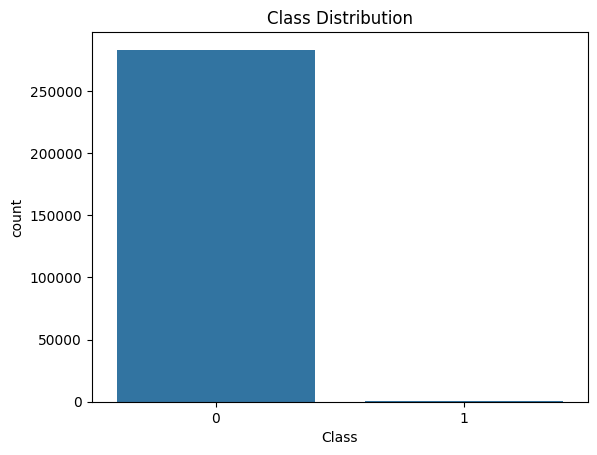

In [9]:
plt.title("Class Distribution")
sns.countplot(x='Class', data=df);

In [10]:
df['Time'] = pd.to_datetime(df['Time'], unit='s', utc=True)
df['hour'] = df['Time'].dt.hour

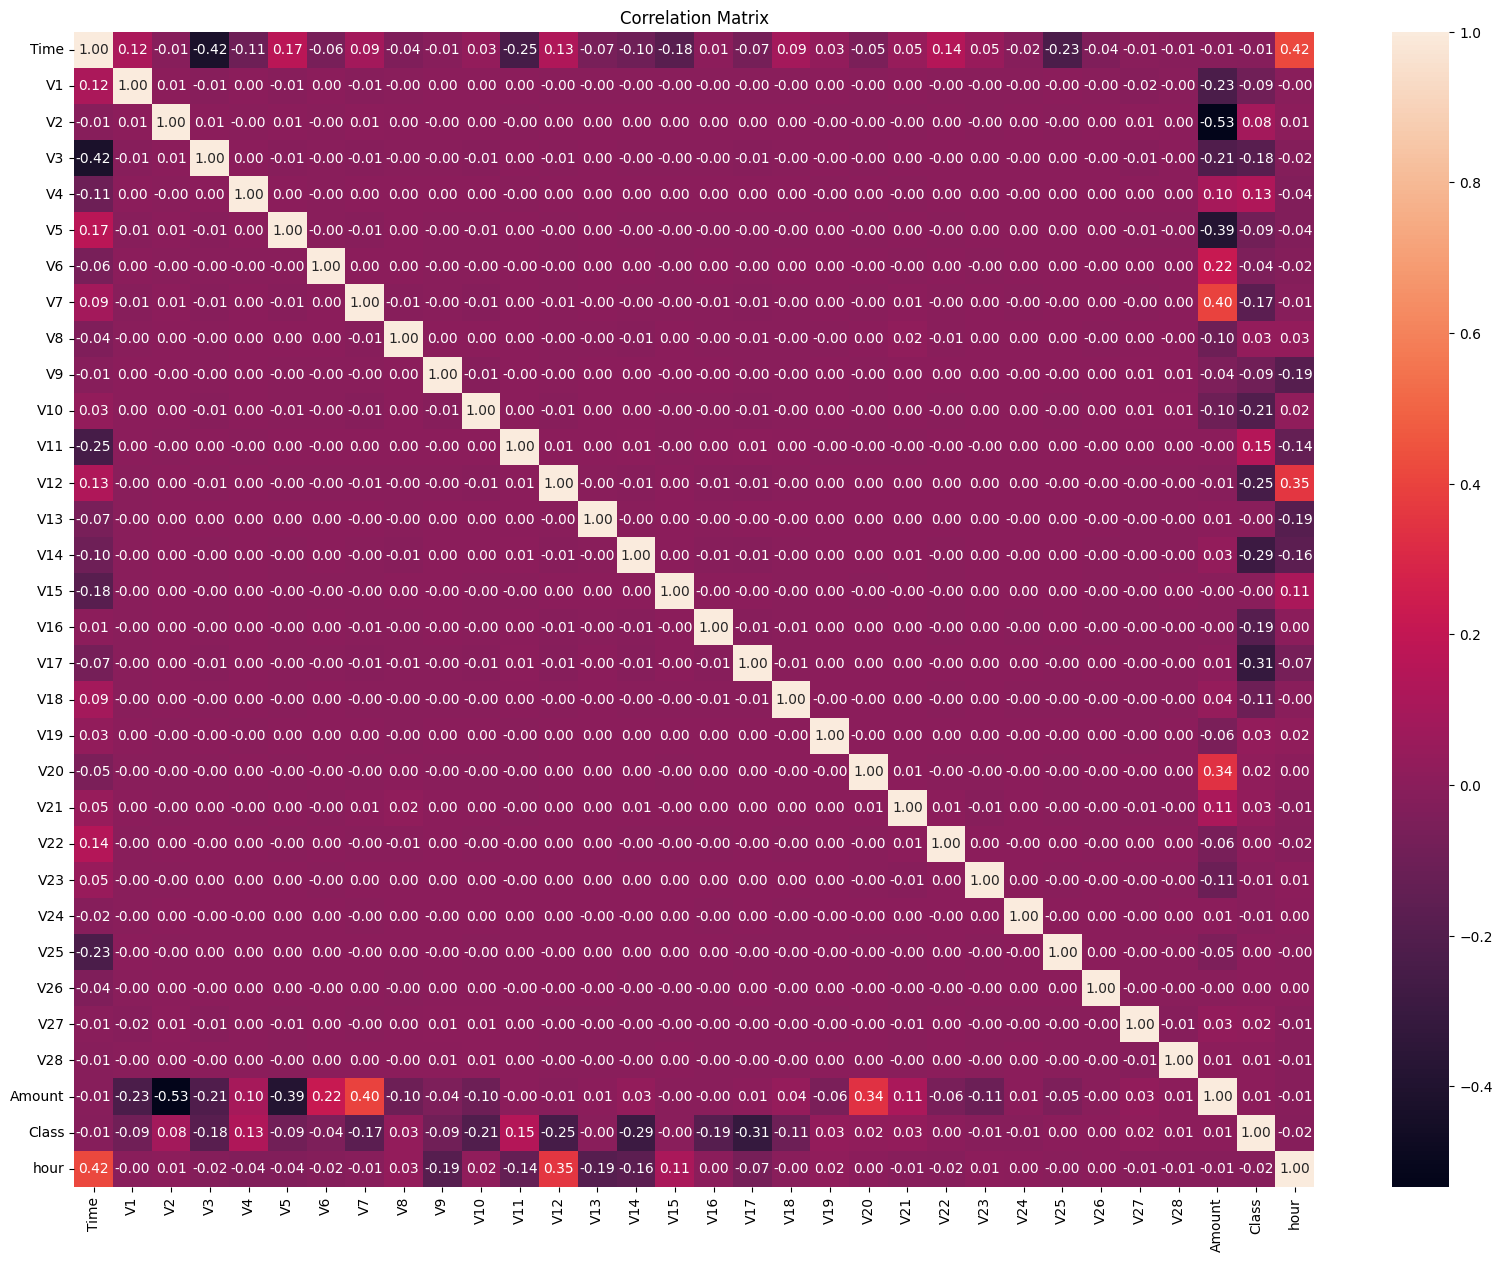

In [11]:
plt.figure(figsize = (20,15))
sns.heatmap(df.corr(),annot=True, fmt= '.2f')
plt.title('Correlation Matrix')
plt.show()

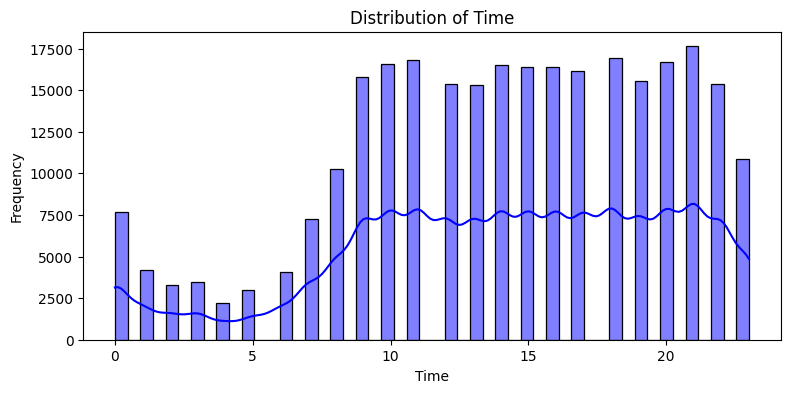

In [12]:
plt.figure(figsize=(9, 4))
sns.histplot(df['hour'], bins = 50, kde = True, color = 'blue')
plt.title('Distribution of Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

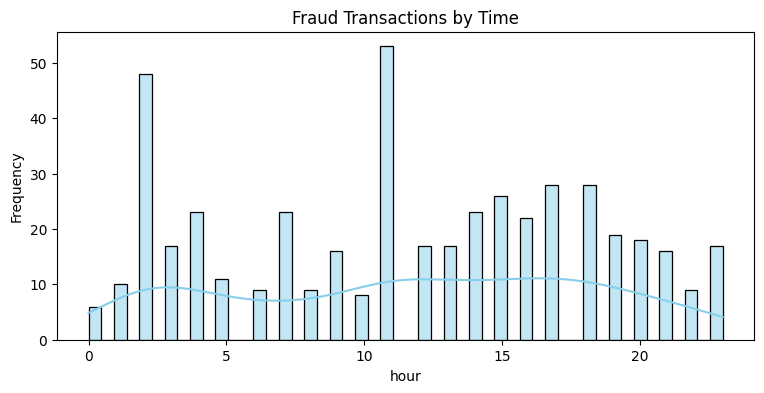

In [13]:
plt.figure(figsize=(9, 4))
fraud = df[df['Class'] == 1]['hour']
plt.title('Fraud Transactions by Time')
plt.ylabel('Frequency')
sns.histplot(fraud, color='skyblue', kde=True, bins=50);

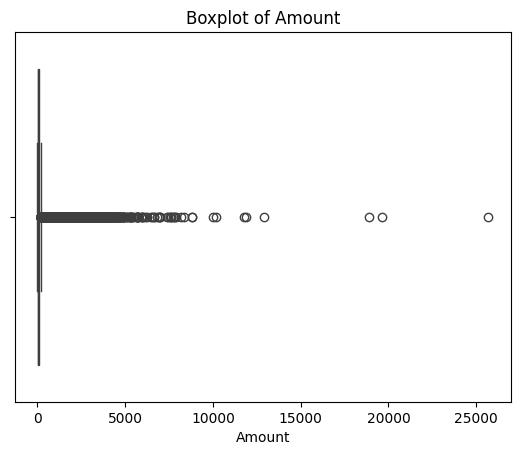

In [14]:
plt.title('Boxplot of Amount')
sns.boxplot(data=df, x='Amount');

In [15]:
x = df.drop(['Class', 'Time'], axis=1)
y = df['Class']

# train test split

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.30, random_state=42)

In [17]:
x_train.shape, y_train.shape

((198608, 30), (198608,))

In [18]:
x_test.shape, y_test.shape

((85118, 30), (85118,))

In [19]:
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier
from imblearn.over_sampling import SMOTE

In [20]:
sm = SMOTE(random_state=42, k_neighbors=3)
x_train, y_train = sm.fit_resample(x_train, y_train)

In [21]:
def evaluation_model(y_actual, y_pred):
    roc = roc_auc_score(y_actual, y_pred)
    precision = precision_score(y_actual, y_pred)
    recall = recall_score(y_actual, y_pred)
    f1 = f1_score(y_actual, y_pred)
    accuracy = accuracy_score(y_actual, y_pred)

    return {
        "ROC_AUC": roc,
        "Precision": precision,
        'accuracy' : accuracy,
        "Recall": recall,
        "F1": f1,
    }

In [22]:

rf = RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42, n_estimators=200)

In [23]:
rf.fit(x_train, y_train)
pred_train = rf.predict(x_train)
pred_test = rf.predict(x_test)

In [24]:
#Training
evaluation_model(y_train, pred_train)

{'ROC_AUC': 1.0, 'Precision': 1.0, 'accuracy': 1.0, 'Recall': 1.0, 'F1': 1.0}

In [25]:
#Testing
evaluation_model(y_test, pred_test)

{'ROC_AUC': 0.8943132410543092,
 'Precision': 0.9256198347107438,
 'accuracy': 0.9995418125425879,
 'Recall': 0.7887323943661971,
 'F1': 0.8517110266159695}

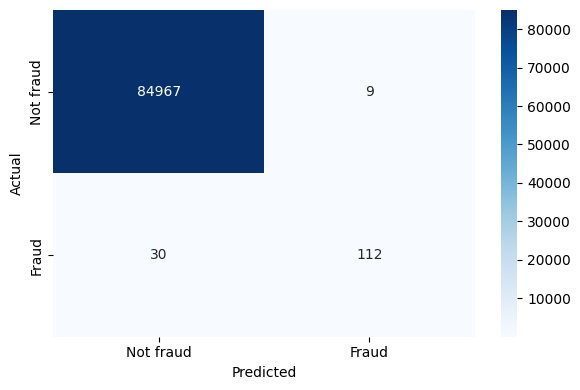

In [26]:

fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test,pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not fraud', 'Fraud'],
            yticklabels=['Not fraud', 'Fraud'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [28]:
pred_test_proba = rf.predict_proba(x_test)
pred_test_proba = pred_test_proba[:, 1]

# --- Impact of Different Thresholds on Fraud Detection Performance ---
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10} | {'Fraud Caught':>13} | {'False Alarms':>13}")
print("-" * 85)

for t in thresholds_to_test:
    preds_t = (pred_test_proba >= t).astype(int)
    report = classification_report(y_test, preds_t, output_dict=True, zero_division=0)
    fraud_caught = preds_t[y_test == 1].sum()
    false_alarms = preds_t[y_test == 0].sum()
    total_fraud = y_test.sum()
    print(f"{t:>10.1f} | {report['1']['precision']:>10.4f} | {report['1']['recall']:>10.4f} | "
          f"{report['1']['f1-score']:>10.4f} | {fraud_caught:>6d}/{total_fraud:<6d} | {false_alarms:>13,}")

 Threshold |  Precision |     Recall |   F1-Score |  Fraud Caught |  False Alarms
-------------------------------------------------------------------------------------
       0.1 |     0.4286 |     0.8451 |     0.5687 |    120/142    |           160
       0.2 |     0.7421 |     0.8310 |     0.7841 |    118/142    |            41
       0.3 |     0.8529 |     0.8169 |     0.8345 |    116/142    |            20
       0.4 |     0.8846 |     0.8099 |     0.8456 |    115/142    |            15
       0.5 |     0.9187 |     0.7958 |     0.8528 |    113/142    |            10
       0.6 |     0.9391 |     0.7606 |     0.8405 |    108/142    |             7
       0.7 |     0.9533 |     0.7183 |     0.8193 |    102/142    |             5
       0.8 |     0.9604 |     0.6831 |     0.7984 |     97/142    |             4


# hyperparameter tunning

In [29]:
import optuna
from sklearn.model_selection import cross_val_score

In [37]:
def hyper_parameter(trail):
    max_depht = trail.suggest_int('max_depth', 5, 15)
    esitimator = trail.suggest_int('n_estimators', 200, 400)
    random_st = trail.suggest_int('random_state', 0, 42)
    bootstrap = trail.suggest_categorical('bootstrap', [True, False])
    
    model = RandomForestClassifier(n_estimators=esitimator, max_depth=max_depht, random_state=random_st, bootstrap=bootstrap, class_weight='balanced')
    model.fit(x_train, y_train)
    score = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy').mean()
    return score
 

In [38]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
study.optimize(hyper_parameter, n_trials=3, n_jobs=-1)

[I 2026-04-12 14:08:45,766] A new study created in memory with name: no-name-4f1ae2cb-a891-4544-87b8-8a933592d898
[I 2026-04-12 14:58:08,521] Trial 1 finished with value: 0.9739051914458183 and parameters: {'max_depth': 7, 'n_estimators': 261, 'random_state': 37, 'bootstrap': True}. Best is trial 1 with value: 0.9739051914458183.
[I 2026-04-12 15:02:21,150] Trial 0 finished with value: 0.9606812678416796 and parameters: {'max_depth': 5, 'n_estimators': 385, 'random_state': 3, 'bootstrap': True}. Best is trial 1 with value: 0.9739051914458183.
[I 2026-04-12 15:26:03,952] Trial 2 finished with value: 0.974212842318311 and parameters: {'max_depth': 7, 'n_estimators': 276, 'random_state': 41, 'bootstrap': False}. Best is trial 2 with value: 0.974212842318311.


In [39]:
study.best_params

{'max_depth': 7, 'n_estimators': 276, 'random_state': 41, 'bootstrap': False}

In [40]:
hyper_rf = RandomForestClassifier(**study.best_params)
hyper_rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",276
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [41]:
hyper_train_pred = hyper_rf.predict(x_train)
hyper_test_pred = hyper_rf.predict(x_test)

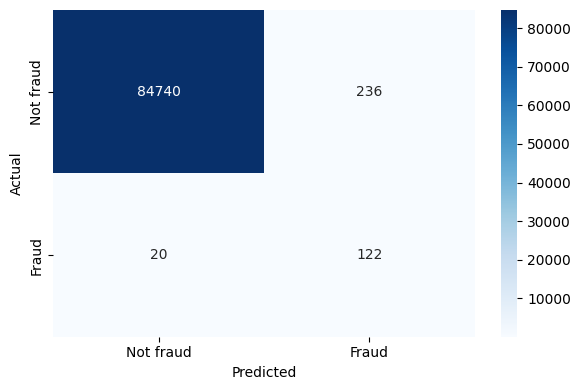

In [42]:

fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, hyper_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not fraud', 'Fraud'],
            yticklabels=['Not fraud', 'Fraud'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [43]:
hyper_pred_test_proba = hyper_rf.predict_proba(x_test)
hyper_pred_test_proba = hyper_pred_test_proba[:, 1]

# --- Impact of Different Thresholds on Fraud Detection Performance ---
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10} | {'Fraud Caught':>13} | {'False Alarms':>13}")
print("-" * 85)

for t in thresholds_to_test:
    preds_t = (hyper_pred_test_proba >= t).astype(int)
    report = classification_report(y_test, preds_t, output_dict=True, zero_division=0)
    fraud_caught = preds_t[y_test == 1].sum()
    false_alarms = preds_t[y_test == 0].sum()
    total_fraud = y_test.sum()
    print(f"{t:>10.1f} | {report['1']['precision']:>10.4f} | {report['1']['recall']:>10.4f} | "
          f"{report['1']['f1-score']:>10.4f} | {fraud_caught:>6d}/{total_fraud:<6d} | {false_alarms:>13,}")

 Threshold |  Precision |     Recall |   F1-Score |  Fraud Caught |  False Alarms
-------------------------------------------------------------------------------------
       0.1 |     0.0108 |     0.9437 |     0.0214 |    134/142    |        12,249
       0.2 |     0.0329 |     0.8873 |     0.0635 |    126/142    |         3,701
       0.3 |     0.1048 |     0.8732 |     0.1872 |    124/142    |         1,059
       0.4 |     0.1922 |     0.8662 |     0.3146 |    123/142    |           517
       0.5 |     0.3408 |     0.8592 |     0.4880 |    122/142    |           236
       0.6 |     0.5472 |     0.8169 |     0.6554 |    116/142    |            96
       0.7 |     0.7600 |     0.8028 |     0.7808 |    114/142    |            36
       0.8 |     0.8661 |     0.7746 |     0.8178 |    110/142    |            17


In [294]:
import pickle

In [296]:
pickle.dump(xg, open('credit_card_fraud.pkl', 'wb'))